# 실습 3-1 : Random Forest

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 분류 데이터 (MachineFailure)
- 회귀 데이터 (Concrete)

2. Random Forest Classifier
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

3. Random Forest Regressor
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

4. 하이퍼 파라미터 최적화
- GridSearchCV를 활용한 최적 파라미터 탐색

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

---

## 1) 분류 문제

In [2]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_cls_data.csv"))
MF_Data.head()

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
0,67,82,Operator1,291,1,1,1041,846,334,706,1086,256,1295,766,968,1185,1355,1842,90,No
1,68,77,Operator1,1180,1,1,1915,1194,637,1093,524,919,245,403,723,1446,719,748,91,No
2,64,76,Operator1,1406,1,1,511,1577,1121,1948,1882,1301,273,1927,1123,717,1518,1689,92,No
3,63,80,Operator1,550,1,1,1754,1834,1413,1151,945,1312,1494,1755,1434,502,1336,711,93,No
4,65,81,Operator1,1928,1,2,1326,1082,233,1441,1736,1033,1549,802,1819,1616,1507,507,94,No


In [3]:
print("데이터 크기 :", MF_Data.shape)
print("출력변수 분포:")
print(MF_Data["Failure"].value_counts())

데이터 크기 : (7900, 20)
출력변수 분포:
Failure
No     7825
Yes      75
Name: count, dtype: int64


In [4]:
# 입출력 변수 분할
Y_cls = MF_Data["Failure"]
X_cls = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X_cls["Measure2"] = X_cls["Measure2"].astype("category")
X_cls["Measure3"] = X_cls["Measure3"].astype("category")
X_cls = pd.get_dummies(X_cls)
cls_columns = X_cls.columns

# 출력변수 인코딩
Y_cls = Y_cls.replace({"No": 0, "Yes": 1})

# 데이터 분할
X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.3, random_state=0, stratify=Y_cls)

print("학습 데이터 :", X_train_cls.shape)
print("테스트 데이터 :", X_test_cls.shape)

학습 데이터 : (5530, 31)
테스트 데이터 : (2370, 31)


/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_94886/2999565116.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_cls = Y_cls.replace({"No": 0, "Yes": 1})


In [5]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

---

### 1-1) Random Forest Classifier 모델 학습 및 성능 평가

> **Random Forest**는 Bagging의 일종으로, 붓스트랩 샘플링 + 무작위 변수 선택을 통해 다수의 의사결정나무를 생성하고 결합하는 앙상블 모델임
> - **붓스트랩 샘플링**: 학습 데이터에서 복원 추출로 여러 표본을 만들어 베이스 모델의 다양성을 확보함
> - **무작위 변수 선택**: 각 노드마다 입력변수의 일부만 랜덤 선택하여 트리 간 상관성을 줄임
> - 분류: 다수결 투표, 회귀: 평균으로 최종 예측을 수행함

In [6]:
RF_cls = RandomForestClassifier()
RF_cls.fit(X_train_cls, Y_train_cls)
RF_cls_pred = RF_cls.predict(X_test_cls)
get_classscore(Y_test_cls, RF_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842

혼동행렬
[[2348    0]
 [   6   16]]


### 1-2) 변수 중요도 시각화

> Random Forest는 **Mean Decrease in Impurity** 방식으로 변수 중요도를 산출함

> 각 트리에서 특정 변수가 노드 분할에 사용될 때의 불순도 감소량을 평균내어 중요도를 계산함

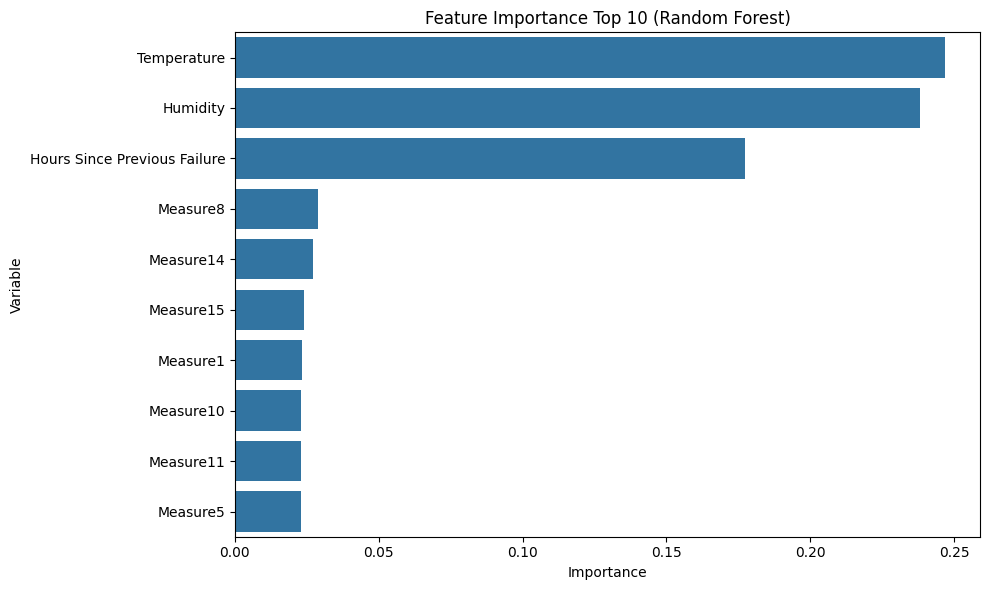

In [8]:
# 변수 중요도 추출 및 시각화
var_imp = pd.DataFrame({"Variable": cls_columns, "Importance": RF_cls.feature_importances_})
imp_top10 = var_imp.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10)
plt.title("Feature Importance Top 10 (Random Forest)")
plt.tight_layout()
plt.show()

### 1-3) 모델 성능 개선

> Random Forest의 주요 하이퍼 파라미터:
>
> | 파라미터 | 의미 |
> |:---:|:---:|
> | n_estimators | 베이스 모델(의사결정나무)의 수 |
> | max_depth | 개별 트리의 최대 깊이 |
> | max_features | 각 노드에서 랜덤 선택하는 변수 수 (분류: sqrt, 회귀: n/3) |
> | min_samples_leaf | 끝 노드의 최소 샘플 수 |
> | min_samples_split | 노드 분할을 위한 최소 샘플 수 |

In [9]:
params = {
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [2, 4, 8],
    "n_estimators": [100, 300],
    "max_features": ["sqrt", 3]
}

grid_cls = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params, cv=5, scoring="f1", n_jobs=-1
)
grid_cls.fit(X_train_cls, Y_train_cls)

print("최적 파라미터:", grid_cls.best_params_)
print("최적 F1-score: %.4f" % grid_cls.best_score_)

최적 파라미터: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
최적 F1-score: 0.8058


In [10]:
# 최적 모델로 테스트 성능 평가
best_pred_cls = grid_cls.predict(X_test_cls)
get_classscore(Y_test_cls, best_pred_cls)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842

혼동행렬
[[2348    0]
 [   6   16]]


---

## 2) 회귀 문제

In [11]:
Concrete = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_reg_data.csv"))

Y_reg = Concrete["Concrete_compressive_strength"]
X_reg = Concrete.drop(["Concrete_compressive_strength"], axis=1)

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)

학습 데이터 : (721, 8)
테스트 데이터 : (309, 8)


In [12]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 2-1) Random Forest Regressor 모델 학습 및 성능 평가

In [13]:
RF_reg = RandomForestRegressor()
RF_reg.fit(X_train_reg, Y_train_reg)
RF_reg_pred = RF_reg.predict(X_test_reg)
get_regscore(Y_test_reg, RF_reg_pred)

MSE       : 27.144
RMSE      : 5.210
MAE       : 3.636
R-squared : 0.894


### 2-2) 변수 중요도 시각화

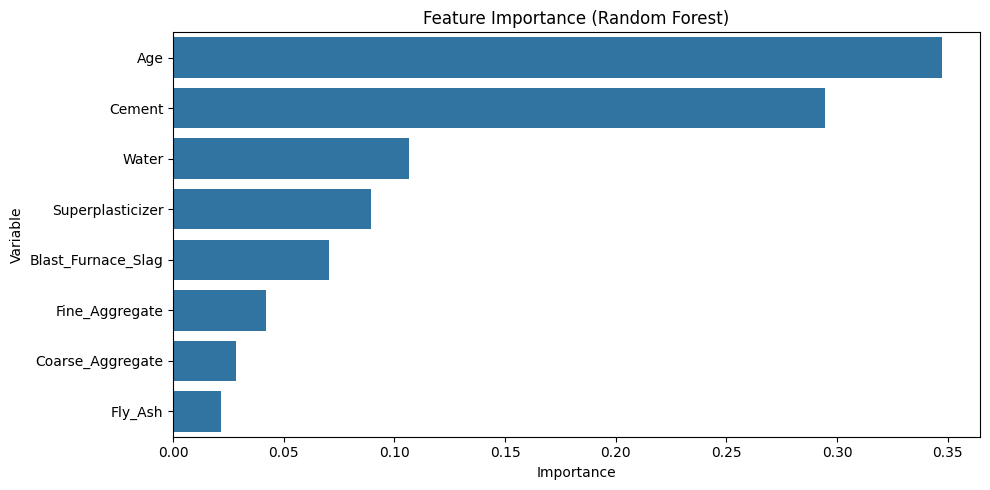

In [14]:
var_imp_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": RF_reg.feature_importances_})
var_imp_reg = var_imp_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_reg)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

### 2-3) 예측 시각화

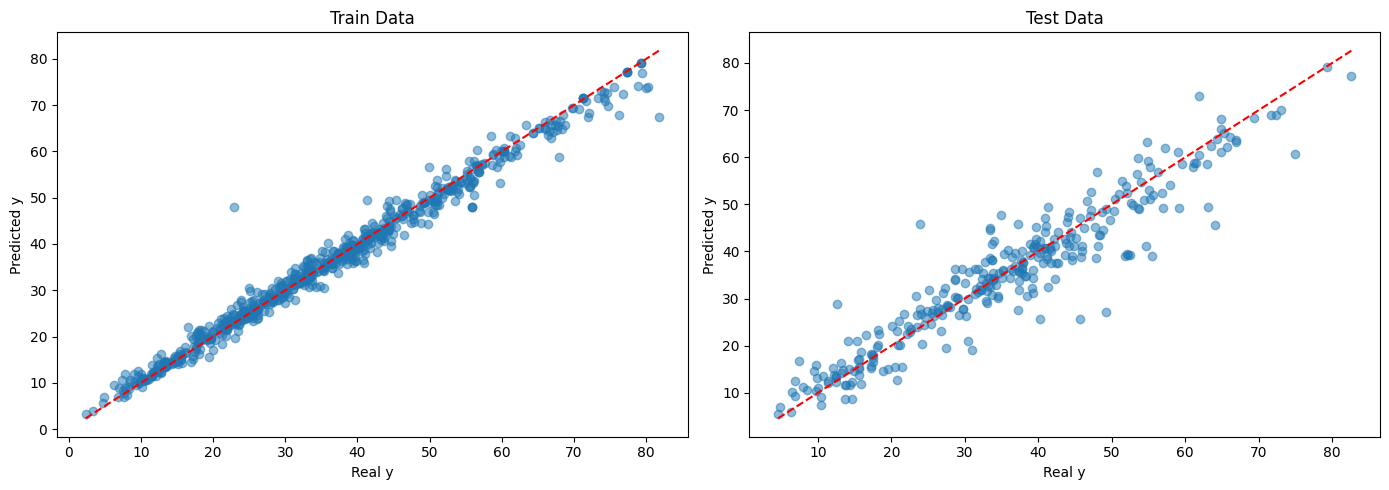

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_train_reg, RF_reg.predict(X_train_reg), alpha=0.5)
axes[0].plot([Y_train_reg.min(), Y_train_reg.max()], [Y_train_reg.min(), Y_train_reg.max()], "r--")
axes[0].set_xlabel("Real y"); axes[0].set_ylabel("Predicted y"); axes[0].set_title("Train Data")

axes[1].scatter(Y_test_reg, RF_reg_pred, alpha=0.5)
axes[1].plot([Y_test_reg.min(), Y_test_reg.max()], [Y_test_reg.min(), Y_test_reg.max()], "r--")
axes[1].set_xlabel("Real y"); axes[1].set_ylabel("Predicted y"); axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

### 2-4) 모델 성능 개선

In [16]:
params_reg = {
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [2, 4],
    "n_estimators": [100, 300]
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid=params_reg, cv=5, scoring="r2", n_jobs=-1
)
grid_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_reg.best_params_)
print("최적 R-squared: %.4f" % grid_reg.best_score_)

최적 파라미터: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 300}
최적 R-squared: 0.8903


In [17]:
# 최적 모델로 테스트 성능 평가
best_pred_reg = grid_reg.predict(X_test_reg)
get_regscore(Y_test_reg, best_pred_reg)

MSE       : 28.213
RMSE      : 5.312
MAE       : 3.785
R-squared : 0.890


---

## 5) Vibe Coding 실습

**[과제 1]**
지수는 Random Forest가 계산한 변수 중요도(Feature Importance)가 정말 중요한 변수를 의미하는지 궁금해졌습니다. AI와 상의하여 변수 중요도를 확인하고, 중요도가 높은 상위 변수만 사용했을 때와 전체 변수를 사용했을 때의 성능을 비교해 보세요. 결과를 바탕으로 "중요한 변수만 사용하면 항상 좋은 모델이 될까?"에 대해 자신의 의견을 정리해 보세요.

In [ ]:
# [프롬프트]

# 회귀 데이터셋과 분류 데이터넷에 대해 Random Forest 모델 결과를 도출했었어.
# 주요하다고 나타난 변수들 몇개만 가지고 학습해도 성능이 비슷한지 궁금한데

# 1. 주요하다고 판단할만한 수치를 말해주고
# 2. 해당 수치 기반으로 했을 때 각 데이터셋에서 유의미한 변수만 남기는 코드를 주고
# 3. 새로운 Random Forest 모델을 학습하고 예측하는 코드 주고
# 4. 모든 변수로 학습했던 것과 주요 변수로만 학습했던 것을 한눈에 비교하는 코드로 줘.

# 한번에 4가지를 다 수행하지말고 1번에 대해서 "ok"를 하면 2번으로 넘어가는 방식으로 해줘

             Variable  Importance
7                 Age    0.347194
0              Cement    0.294582
3               Water    0.106435
4    Superplasticizer    0.089169
1  Blast_Furnace_Slag    0.070569
6      Fine_Aggregate    0.042165
5    Coarse_Aggregate    0.028469
2             Fly_Ash    0.021416


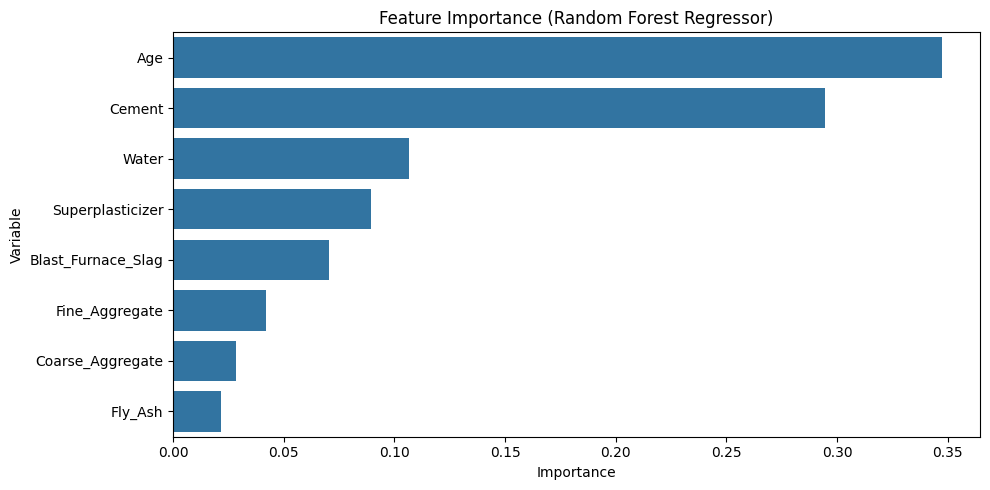

In [19]:
var_imp_reg = pd.DataFrame({
    "Variable": X_train_reg.columns,
    "Importance": RF_reg.feature_importances_
}).sort_values("Importance", ascending=False)

print(var_imp_reg)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_reg)
plt.title("Feature Importance (Random Forest Regressor)")
plt.tight_layout()
plt.show()

In [20]:
top_k = 5  # 상위 5개 (필요하면 3, 8 등으로 변경)
top_cols = var_imp_reg.head(top_k)["Variable"].tolist()

RF_all = RandomForestRegressor(random_state=0)
RF_all.fit(X_train_reg, Y_train_reg)

RF_top = RandomForestRegressor(random_state=0)
RF_top.fit(X_train_reg[top_cols], Y_train_reg)

print("사용 변수 (Top):", top_cols)
print()

for name, model, X_tr, X_te in [
    ("All features", RF_all, X_train_reg, X_test_reg),
    (f"Top {top_k} features", RF_top, X_train_reg[top_cols], X_test_reg[top_cols]),
]:
    pred = model.predict(X_te)
    print(f"=== {name} ===")
    get_regscore(Y_test_reg, pred)
    print()

사용 변수 (Top): ['Age', 'Cement', 'Water', 'Superplasticizer', 'Blast_Furnace_Slag']

=== All features ===
MSE       : 26.749
RMSE      : 5.172
MAE       : 3.573
R-squared : 0.896

=== Top 5 features ===
MSE       : 25.610
RMSE      : 5.061
MAE       : 3.619
R-squared : 0.900



**[과제 2]** 지수는 Random Forest가 단일 의사결정나무보다 항상 더 좋은 성능을 보이는지 궁금해졌습니다. 동일한 데이터로 단일 의사결정나무 모델을 학습시켜 이번 실습의 Random Forest 모델과 성능을 비교해 보세요. 그리고 그 차이가 나타나는 이유를 AI와 상의하여 해석해 보세요.

In [21]:
from sklearn.tree import DecisionTreeRegressor

# 단일 의사결정나무
DT_reg = DecisionTreeRegressor(random_state=0)
DT_reg.fit(X_train_reg, Y_train_reg)

# 성능 비교
for name, model in [("Decision Tree", DT_reg), ("Random Forest", RF_reg)]:
    pred = model.predict(X_test_reg)
    print(f"=== {name} ===")
    get_regscore(Y_test_reg, pred)
    print()

=== Decision Tree ===
MSE       : 58.071
RMSE      : 7.620
MAE       : 4.844
R-squared : 0.774

=== Random Forest ===
MSE       : 27.144
RMSE      : 5.210
MAE       : 3.636
R-squared : 0.894



**[과제 3]** 지수는 Random Forest의 성능을 더 높이기 위해 하이퍼파라미터 튜닝을 시도하려고 합니다. 하지만 n_estimators, max_depth, min_samples_split, max_features 등의 의미와 적절한 범위를 잘 모릅니다. AI와 상의하여 각 하이퍼파라미터의 역할을 이해하고 탐색 범위를 직접 설정해 보세요. 이후 GridSearchCV를 활용해 최적의 조합을 찾고, 왜 해당 조합이 선택되었는지 결과를 해석해 보세요.

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

params_reg = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0],
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=0, n_jobs=-1),
    param_grid=params_reg,
    cv=5,
    scoring="neg_root_mean_squared_error",  # RMSE 기준 (클수록 좋음 → 음수)
    n_jobs=-1
)

grid_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_reg.best_params_)
print("CV RMSE:", -grid_reg.best_score_)

# 최적 모델 테스트 성능
RF_best = grid_reg.best_estimator_
pred = RF_best.predict(X_test_reg)
get_regscore(Y_test_reg, pred)

최적 파라미터: {'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
CV RMSE: 5.384876624688334
MSE       : 24.896
RMSE      : 4.990
MAE       : 3.494
R-squared : 0.903


**[과제 4]**
지수는 Random Forest에서 나무의 개수(n_estimators)를 많이 늘릴수록 성능이 계속 좋아지는지 궁금해졌습니다. AI와 상의하여 다양한 n_estimators 값(예: 10, 50, 100, 200, 500 등)으로 모델을 학습시키고 성능 변화를 그래프로 시각화해 보세요. 성능 향상과 학습 시간의 변화를 함께 확인한 뒤, 실무에서는 어떤 값을 선택하는 것이 적절할지 의견을 정리해 보세요.